# 生成伪实验数据

包含：单比特、两比特态层析测量数据

In [1]:
!python src/tomography/generate_data.py --n_qubits 1 --state + --shots 6000 --out data/test_tomography_1q.npz
!python src/tomography/generate_data.py --n_qubits 2 --state phi+ --shots 5000 --out data/test_tomography_2q.npz

Wrote data/test_tomography_1q.npz
Wrote data/test_tomography_2q.npz


In [4]:
from src.tomography.io import load_npz, save_json

ds = load_npz("data/test_tomography_1q.npz")

ds

{'n_qubits': 1,
 'counts': array([[5762,  238],
        [3022, 2978],
        [2990, 3010]]),
 'A_meas': array([[0.96, 0.05],
        [0.04, 0.95]], dtype=float32),
 'settings': array(['X', 'Y', 'Z'], dtype=object),
 'meta_json': {'state': '+',
  'shots_per_setting': 6000,
  'seed': 0,
  'confusion_single_qubit': {'p01': 0.04, 'p10': 0.05},
  'convention': 'q_obs = A_meas @ p_true ; columns=true, rows=observed',
  'settings_order_1q': ['X', 'Y', 'Z'],
  'outcome_order_1q': ['+', '-']}}

In [32]:
# result_1q = run_tomography.py --in_npz data/test_tomography_1q.npz
import subprocess
import json 

result = subprocess.run(['python', 'test/run_tomography.py', '--data', 'data/test_tomography_1q.npz', '--device', 'cuda'],
                        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
result_1q_cuda = json.loads(result.stdout)

result = subprocess.run(['python', 'test/run_tomography.py', '--data', 'data/test_tomography_1q.npz', '--device', 'cpu'],
                        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
result_1q_cpu = json.loads(result.stdout)

result = subprocess.run(['python', 'test/run_tomography.py', '--data', 'data/test_tomography_2q.npz', '--device', 'cuda'],
                        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
result_2q_cuda = json.loads(result.stdout)

result = subprocess.run(['python', 'test/run_tomography.py', '--data', 'data/test_tomography_2q.npz', '--device', 'cpu'],
                        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
result_2q_cpu = json.loads(result.stdout)


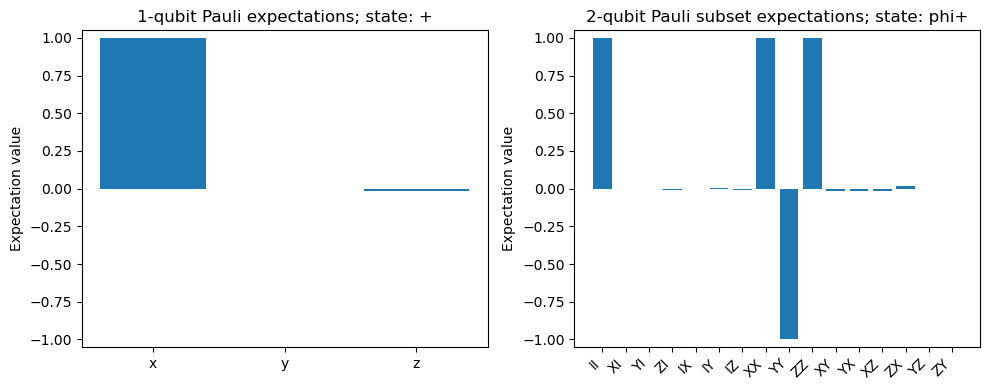

In [48]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
bloch = result_1q_cuda["bloch"]
labels = ["x","y","z"]
values = [bloch["x"], bloch["y"], bloch["z"]]
plt.bar(labels, values)
plt.ylim(-1.05, 1.05)
plt.title(f"1-qubit Pauli expectations; state: {result_1q_cuda['meta']['state']}")
plt.ylabel("Expectation value")

plt.subplot(1,2,2)
pauli = result_2q_cuda["pauli_expectations"]
keys = ["II","XI","YI","ZI","IX","IY","IZ","XX","YY","ZZ","XY","YX","XZ","ZX","YZ","ZY"]
labels = [k for k in keys if k in pauli]
values = [pauli[k] for k in labels]
plt.bar(range(len(labels)), values)
plt.ylim(-1.05, 1.05)
plt.title(f"2-qubit Pauli subset expectations; state: {result_2q_cuda['meta']['state']}")
plt.ylabel("Expectation value")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()
# plt.savefig(args.out_png, dpi=200)
# print(f"Wrote {args.out_png}")
